# Introduction
## Objective

Develop a Customer Intelligence System using Classification, Ensemble Learning, and Clustering techniques to analyze socioeconomic and health indicators and identify country development patterns.

## 1. Import Required Libraries

In [27]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

## 2. Loading the Dataset

In [2]:
df=pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Understanding the Dataset

In [7]:
print("Shape:",df.shape)


Shape: (167, 10)


The Dataset consists of 167 rows and 10 Columns


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None


In [8]:

print(df.describe())

       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.810000    0.065900     609.000000   
25%      8.250000   23.800000    4.920000   30.200000    3355.000000   
50%     19.300000   35.000000    6.320000   43.300000    9960.000000   
75%     62.100000   51.350000    8.600000   58.750000   22800.000000   
max    208.000000  200.000000   17.900000  174.000000  125000.000000   

        inflation  life_expec   total_fer           gdpp  
count  167.000000  167.000000  167.000000     167.000000  
mean     7.781832   70.555689    2.947964   12964.155689  
std     10.570704    8.893172    1.513848   18328.704809  
min     -4.210000   32.100000    1.150000     231.000000  
25%      1.810000   65.300000    1.795000    1330.000000

In [9]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


## 4. Exploratory Data Analysis (EDA)
### 4.1 Distribution of Numerical Features
Purpose

Understand the distribution of each variable and identify skewness.

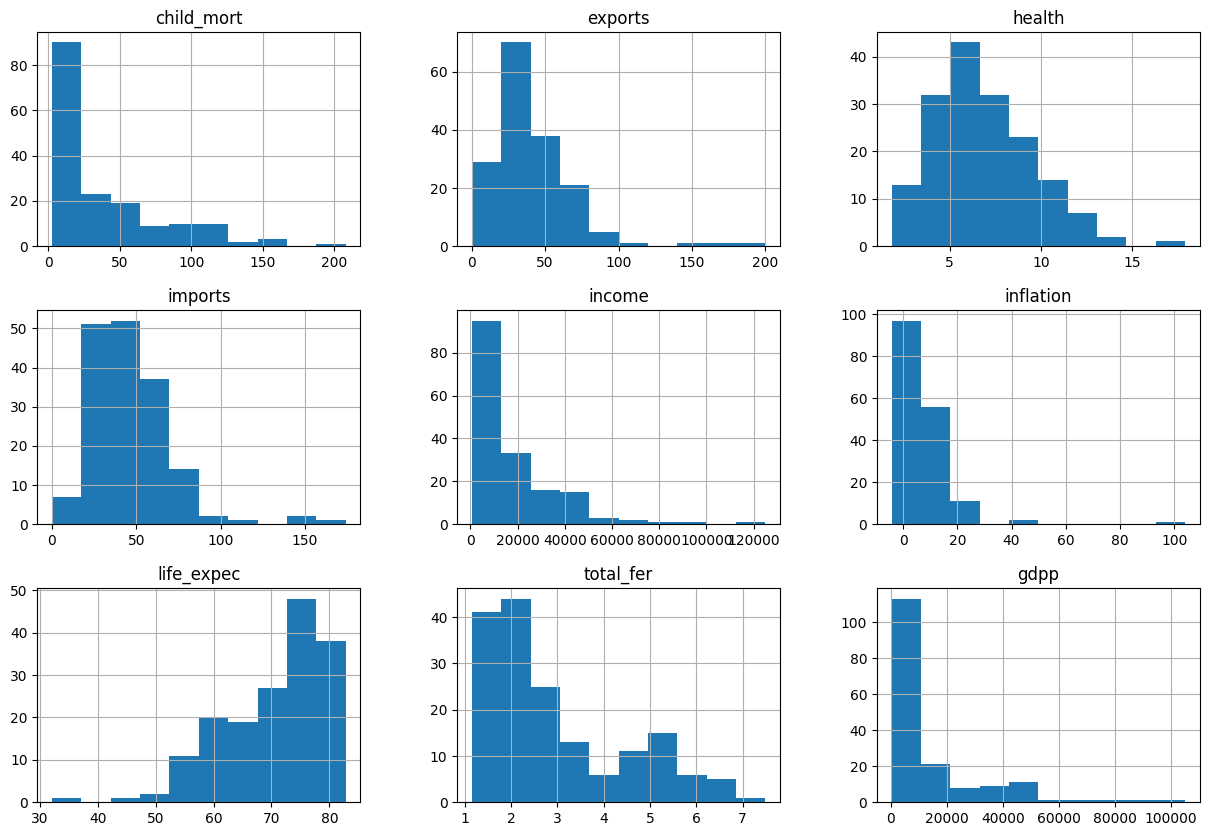

In [14]:
#EDA
#Numerical Distribution
df.hist(figsize=(15,10))
plt.show()

### 4.2 Outlier Detection using Boxplots
Purpose

Identify extreme values present in the dataset.

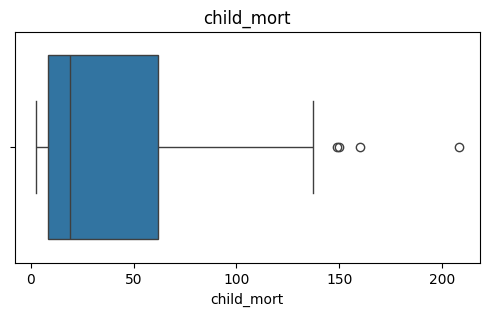

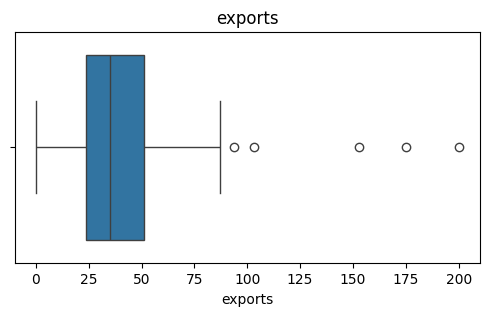

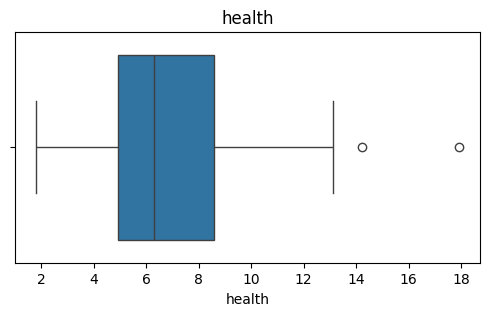

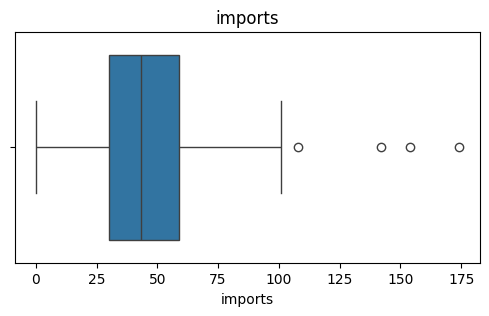

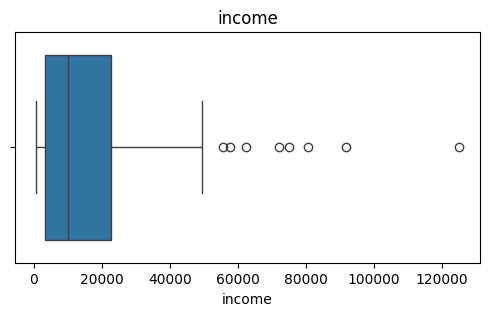

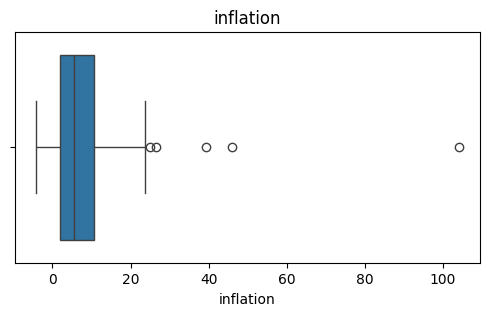

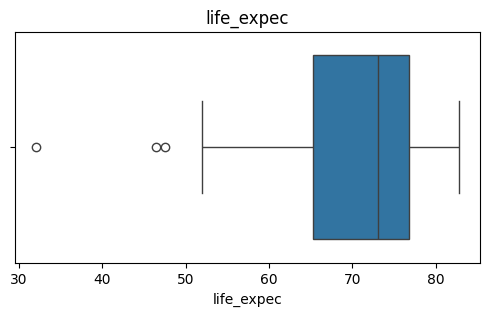

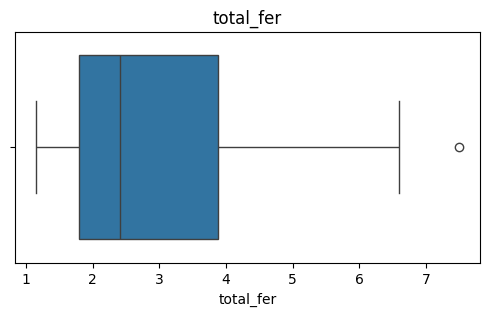

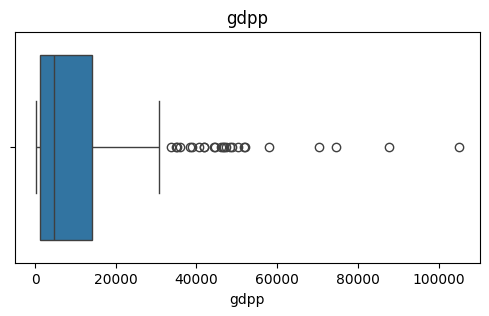

In [15]:
#Boxplots
for col in df.columns[1:]:
  plt.figure(figsize=(6,3))
  sns.boxplot(x=df[col])
  plt.title(col)
  plt.show()

### 4.3 Correlation Analysis
Purpose

Examine relationships between socioeconomic and health indicators.

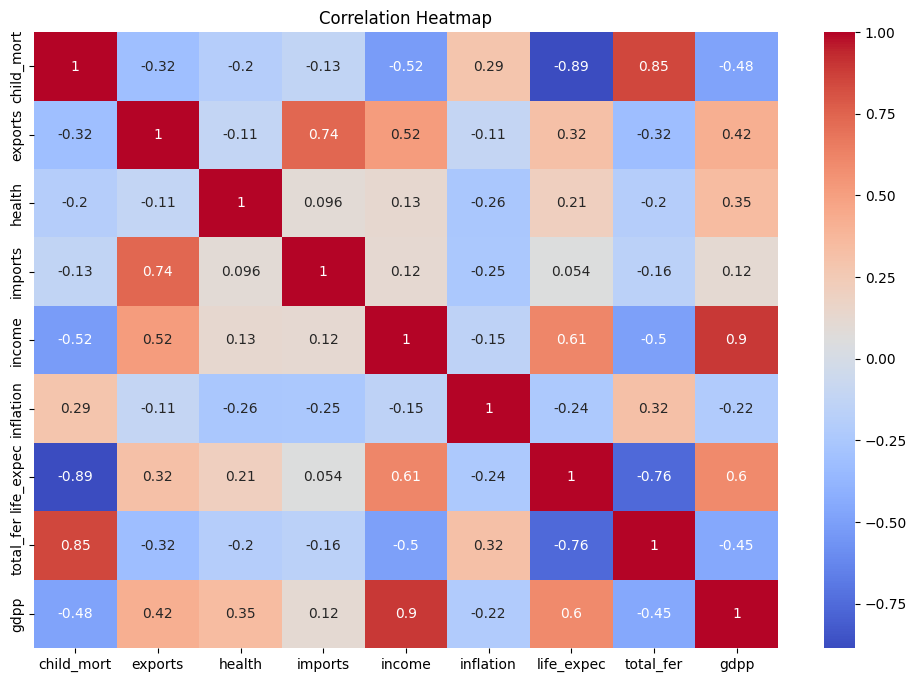

In [16]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.drop('country',axis=1).corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### 4.4 Income vs GDP Analysis
Purpose

Study the relationship between national income and GDP per capita.

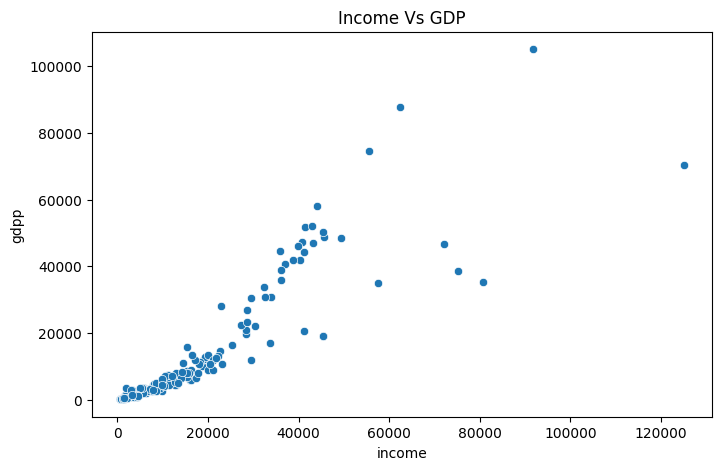

In [17]:
#Income VS GDP
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='income',y='gdpp')
plt.title("Income Vs GDP")
plt.show()

### 5.5 Life Expectancy vs Child Mortality
Purpose

Investigate how child mortality influences life expectancy.

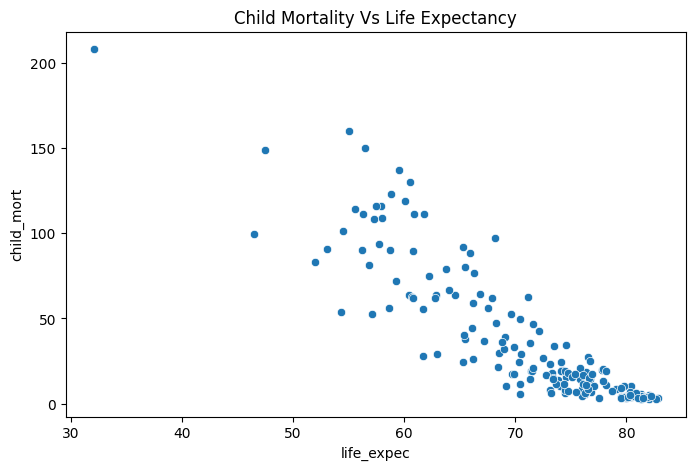

In [19]:
#Life Expectancy vs Child Mortality
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='life_expec',y='child_mort')
plt.title("Child Mortality Vs Life Expectancy")
plt.show()

## 5. Feature Engineering
Creating Development Status Categories
Purpose

Since the dataset does not contain a target variable, a Development Status feature is created using GDP per capita thresholds.

In [21]:
# Feature Engineering
def development_status(gdpp):
  if gdpp>=15000:
    return "Developed"
  elif gdpp>=5000:
    return "Developing"
  else:
    return "Underdeveloped"

In [22]:
df['Development_Status']=df['gdpp'].apply(development_status)


In [23]:
df['Development_Status'].value_counts()

,count
Development_Status,
Underdeveloped,85
Developing,41
Developed,41


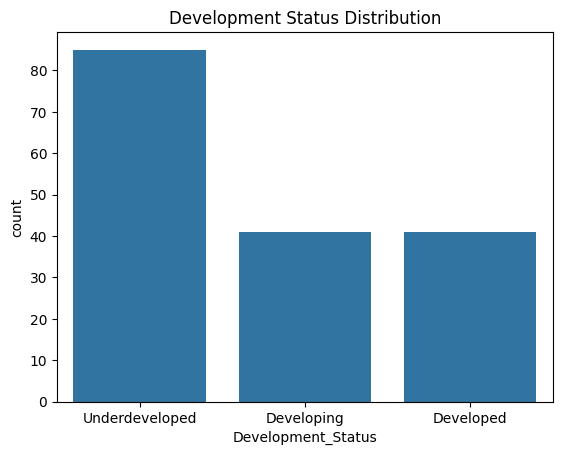

In [24]:
sns.countplot(x='Development_Status',data=df)
plt.title("Development Status Distribution")
plt.show()

## 6.Data Preprocessing

In [26]:
X=df.drop(['country','Development_Status'],axis=1)
y=df['Development_Status']

In [28]:
le=LabelEncoder()
y=le.fit_transform(y)


In [29]:
sc=StandardScaler()
X_scaled=sc.fit_transform(X)

In [30]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## 7.Random Forest Classification

In [33]:
rf=RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)

In [34]:
print("Accuracy:",accuracy_score(y_test,rf_pred))

Accuracy: 0.9705882352941176


In [35]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        16

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



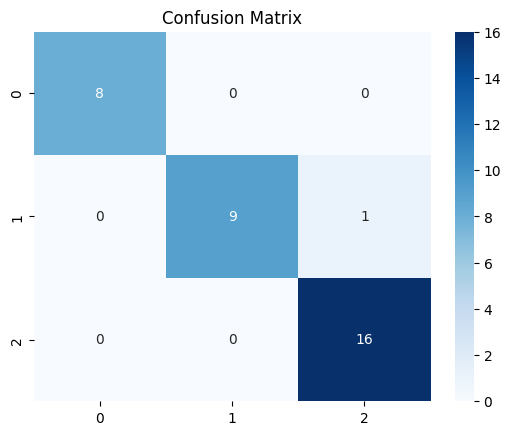

In [36]:
cm=confusion_matrix(y_test,rf_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [38]:
#Feature Importance
importance=pd.Series(rf.feature_importances_,index=X.columns)

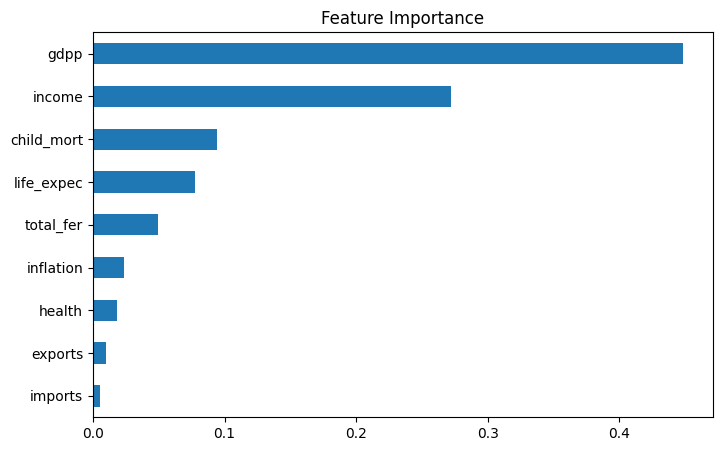

In [39]:
importance.sort_values().plot(kind='barh',figsize=(8,5))
plt.title("Feature Importance")
plt.show()

## 9.XGBoost Classification

In [74]:
xgb=XGBClassifier(n_estimators=200,random_state=42,max_depth=4,learning_rate=0.01)
xgb.fit(X_train,y_train)
xgb_pred=xgb.predict(X_test)

In [75]:
print("Accuracy:",accuracy_score(y_test,xgb_pred))

Accuracy: 1.0


In [76]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        16

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



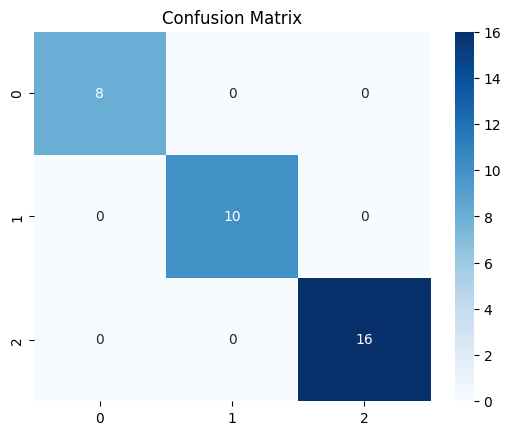

In [77]:
cm=confusion_matrix(y_test,xgb_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## 10.Model Comparison

In [113]:
results = pd.DataFrame({'Model':['Random Forest','XGBoost'],'Accuracy':[accuracy_score(y_test,rf_pred),accuracy_score(y_test,xgb_pred)]})

results

,Model,Accuracy
0,Random Forest,0.970588
1,XGBoost,1.000000


## 11.K-Means Clustering

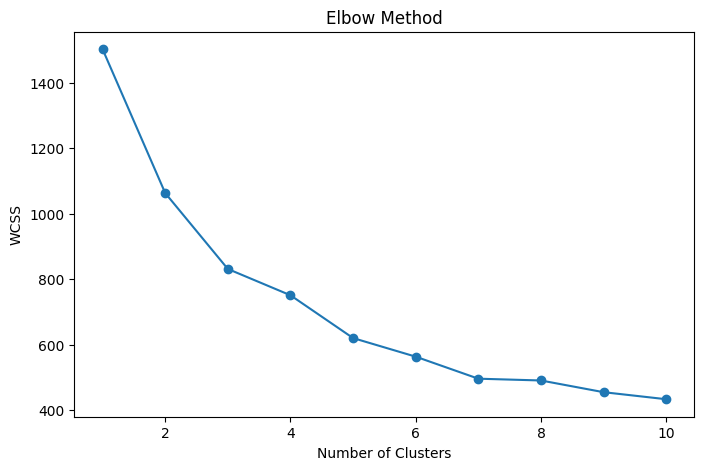

In [96]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [103]:
kmeans = KMeans(n_clusters=3,random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [80]:
df['KMeans_Cluster'] = clusters

In [104]:
print(silhouette_score(X_scaled,clusters))

0.285600988953231


## 12.DBSCAN Clustering

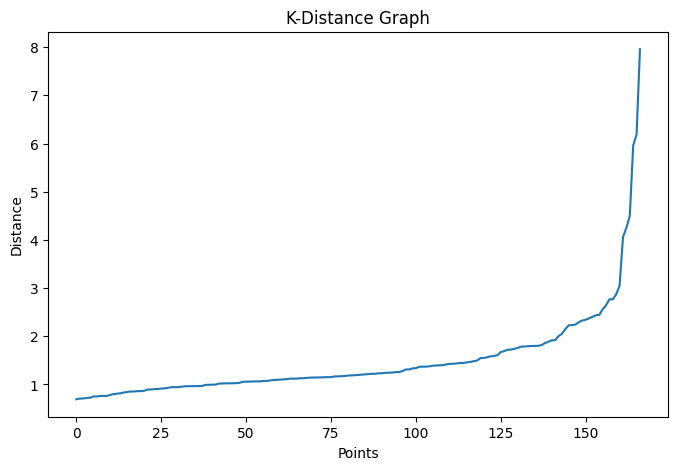

In [97]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4])
plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("K-Distance Graph")
plt.xlabel("Points")
plt.ylabel("Distance")

plt.show()

In [105]:
dbscan = DBSCAN(eps=1.5,min_samples=5)

db_clusters = dbscan.fit_predict(X_scaled)
print(pd.Series(db_clusters).value_counts())

 0    137
-1     30
Name: count, dtype: int64


In [106]:
df['DBSCAN_Cluster'] = db_clusters

In [101]:
print("Number of Clusters:",len(set(db_clusters)))

Number of Clusters: 2


## 13.Cluster Profiling and Interpretation

In [107]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [108]:
cluster_profile = (df.groupby('KMeans_Cluster').mean(numeric_only=True))

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster,Aid_Score
KMeans_Cluster,,,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442,-0.069767,-47.768953
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000,-73.375000
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111,-0.333333,41.116444


In [109]:
cluster_names = {0: 'Developed',1: 'Developing',2: 'Underdeveloped'}

df['Cluster_Label'] = (df['KMeans_Cluster'].map(cluster_names))

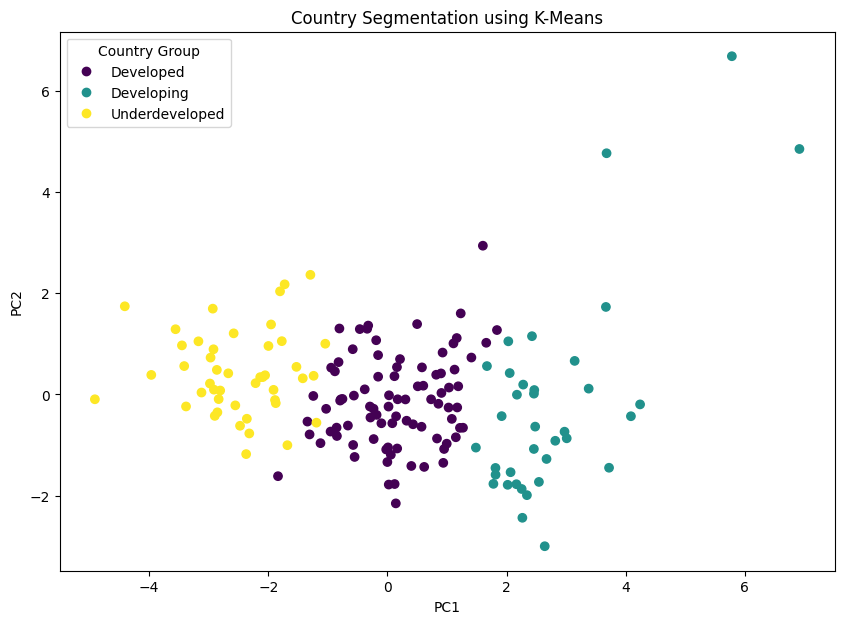

In [95]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(X_pca[:,0],X_pca[:,1],c=clusters,cmap='viridis')

plt.legend(handles=scatter.legend_elements()[0],labels=['Developed','Developing','Underdeveloped'],title='Country Group')

plt.title('Country Segmentation using K-Means')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.show()

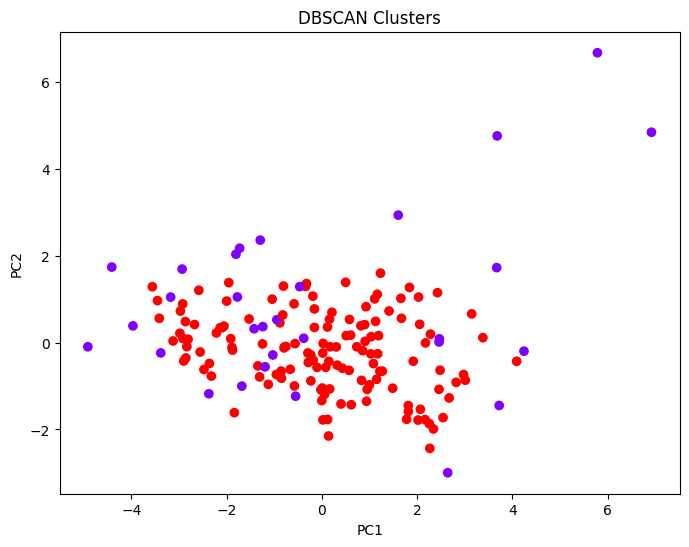

In [87]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0],X_pca[:,1],c=db_clusters,cmap='rainbow')

plt.title("DBSCAN Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [110]:
cluster_profile = (df.groupby('KMeans_Cluster').mean(numeric_only=True))

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster,Aid_Score
KMeans_Cluster,,,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442,-0.069767,-47.768953
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000,-73.375000
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111,-0.333333,41.116444


## 14. Identification of Countries Requiring Development Assistance

In [111]:
df['Aid_Score'] = (df['child_mort']+ df['total_fer']- df['life_expec'])

In [112]:
df[['country','Aid_Score']].sort_values(by='Aid_Score',ascending=False).head(10)

,country,Aid_Score
66,Haiti,179.23
132,Sierra Leone,110.20
31,Central African Republic,106.71
32,Chad,100.09
97,Mali,84.05
113,Nigeria,75.34
112,Niger,71.69
3,Angola,65.06
37,"Congo, Dem. Rep.",65.04
25,Burkina Faso,63.97


## 15. Key Insights
- GDP per capita and income showed a strong positive relationship, indicating higher economic development.

- Child mortality was negatively correlated with life expectancy, highlighting the impact of healthcare on development.
- Random Forest and XGBoost effectively classified countries based on socioeconomic and health indicators.
- K-Means successfully segmented countries into Developed, Developing, and Underdeveloped groups.
- DBSCAN identified 30 outlier countries with unique development characteristics.
- Aid Score analysis helped identify countries requiring priority development assistance.

## 16. Conclusion
This project successfully applied classification and clustering techniques to analyze country development patterns. Random Forest, XGBoost, K-Means, and DBSCAN provided valuable insights into socioeconomic and health indicators. The results helped classify countries, identify development-based clusters, and highlight countries requiring greater support, demonstrating the usefulness of machine learning for data-driven decision-making.